In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

sns.set_style('ticks',
              rc={'axes.facecolor': (0, 0, 0, 0)})
sns.set_context('paper')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['figure.dpi'] = 150

In [2]:
from scipy import integrate

In [3]:
import numpy as np
import pandas as pd
from scipy.integrate import trapezoid

In [4]:
def lighten_color(color, amount=0.55):
    c = mcolors.to_rgb(color)
    white = (1, 1, 1)
    return tuple((1 - amount) * x + amount * y for x, y in zip(c, white))

In [5]:
strains_order = ['PL', 'PM', 'LM',
                 'PL+PM', 'LM+PL', 'LM+PM',
                 'TriComm']
media_order = ['M9',
               'M9+Lys', 'M9+Met', 'M9+Phe',
               'M9+Lys+Met', 'M9+Lys+Phe', 'M9+Met+Phe',
               'M9+Lys+Met+Phe']
base_colors= [
              'xkcd:teal',
              'xkcd:salmon',
              'xkcd:dark grey',

              '#8B5FBF',
              '#0072B2',
              '#CCB974',

              '#882255'
              ]
ds = {'PL': 'Single',
      'PM': 'Single',
      'LM': 'Single',
      'PL+PM': 'Double',
      'LM+PL': 'Double',
      'LM+PM': 'Double',
      'TriComm': 'TriComm'}
dm = {'M9': 'M9',
      'M9+Lys': 'M9+1AA',
      'M9+Met': 'M9+1AA',
      'M9+Phe': 'M9+1AA',
      'M9+Lys+Met': 'M9+2AA',
      'M9+Lys+Phe': 'M9+2AA',
      'M9+Met+Phe': 'M9+2AA',
      'M9+Lys+Met+Phe': 'M9+Lys+Met+Phe'}

In [6]:
m1 = pd.read_csv('../data/batch/rep_1.tsv', sep='\t')
m2 = pd.read_csv('../data/batch/rep_2.tsv', sep='\t')
m = pd.concat([m1, m2])
m['time'] = m['time'] / 60 / 60
m['replicate'] = ['rep1' if x == 'growth_rate_20260720'
                  else 'rep2'
                  for x in m['experiment'].values]

In [7]:
m['scateg'] = [ds[x] for x in m['strain'].values]
m['mcateg'] = [dm[x] for x in m['treatment'].values]

In [8]:
a = m.groupby(['strain', 'replicate', 'treatment', 'row', 'column']
         ).apply(lambda x:
                 trapezoid(x['od600'], x['time']),
                 include_groups=False
                ).reset_index().rename(columns={0: 'auc'})

In [9]:
a['scateg'] = [ds[x] for x in a['strain'].values]
a['mcateg'] = [dm[x] for x in a['treatment'].values]

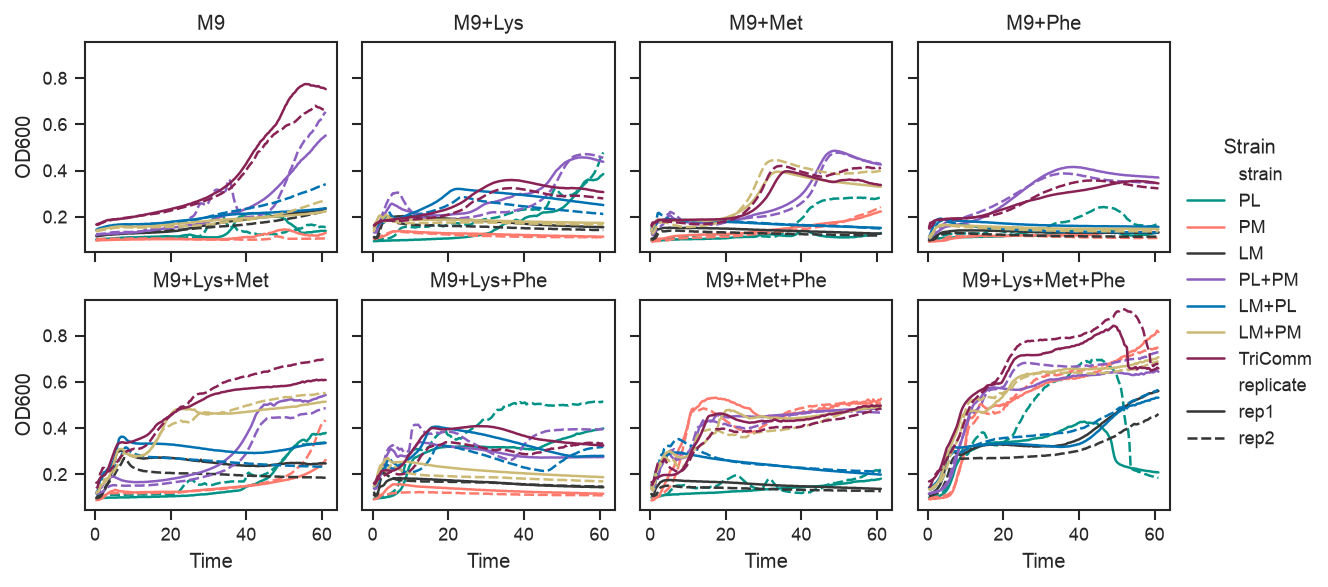

In [10]:
rp = sns.relplot(data=m,
                 x='time',
                 y='od600',
                 col='treatment',
                 hue='strain',
                 style='replicate',
                 kind='line',
                 errorbar=None,
                 col_wrap=4,
                 height=2,
                 palette=base_colors,
                hue_order=strains_order,
                col_order=media_order)

# change legend title
rp._legend.set_title('Strain')

rp.set(xlabel='Time', ylabel='OD600')
rp.set_titles('{col_name}')

plt.subplots_adjust(wspace=0.1, hspace=0.225)

sns.despine(top=False, right=False)

plt.savefig('curves_all.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('curves_all.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

In [11]:
m['well'] = [f'{x}{y}' for x, y in zip(m['row'], m['column'])]

/home/galmar/miniforge3/envs/2026_tricomm/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 16.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


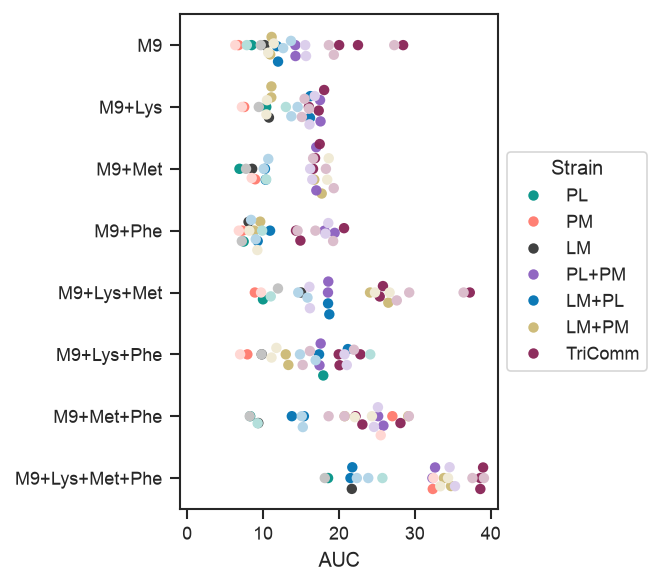

In [12]:
fig, ax = plt.subplots(figsize=(4.5, 4))

a1 = a[a["replicate"] == "rep1"]
a2 = a[a["replicate"] == "rep2"]

sns.swarmplot(
    data=a1,
    y="treatment",
    x="auc",
    hue="strain",
    order=media_order,
    hue_order=strains_order,
    palette=base_colors,
    alpha=0.95,
    ax=ax
)

light_palette = [lighten_color(x, 0.7) for x in base_colors]

sns.swarmplot(
    data=a2,
    y="treatment",
    x="auc",
    hue="strain",
    order=media_order,
    hue_order=strains_order,
    palette=light_palette,
    # alpha=0.7,
    ax=ax
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:len(strains_order)], labels[:len(strains_order)],
          title="Strain", bbox_to_anchor=(1, 0.5), loc="center left",
          facecolor='w')

ax.set(xlabel="AUC", ylabel="", xlim=(-1, 41))
sns.despine(top=False, right=False)
plt.tight_layout()

plt.savefig('curves_auc_all.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('curves_auc_all.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

In [13]:
b = a.pivot_table(index='strain', columns='treatment', values='auc',
                  aggfunc='mean'
                 ).reindex(strains_order).reindex(media_order, axis=1)

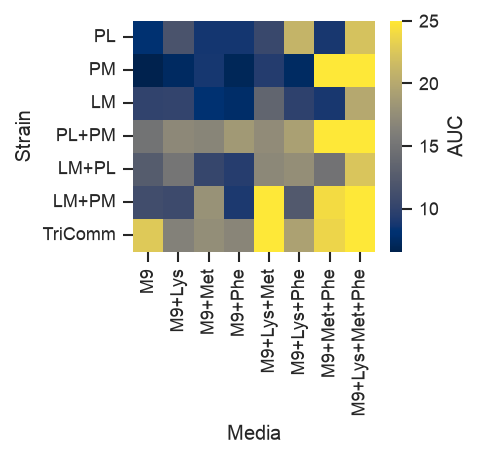

In [14]:
plt.figure(figsize=(2.6, 2))

# use smaller font sizes for this one
with sns.axes_style('ticks', rc={'font.size': 5, 'axes.labelsize': 5}):
    hm = sns.heatmap(data=b,
                     cmap='cividis',
                     vmax=25,
                    )

    hm.figure.axes[-1
        ].set_ylabel('AUC')
    
    plt.xlabel('Media')
    plt.ylabel('Strain')

plt.savefig('curves_auc_hm_all.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('curves_auc_hm_all.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

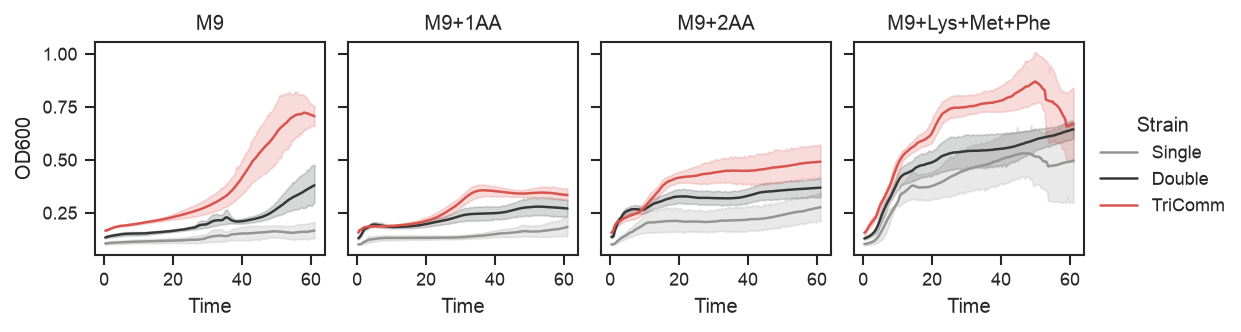

In [15]:
rp = sns.relplot(data=m[~((m['time'] > 23) & (m['time'] < 25))],
                 x='time',
                 y='od600',
                 col='mcateg',
                 hue='scateg',
                 kind='line',
                 # style='replicate',
                 errorbar='ci',
                 # errorbar=None,
                 col_wrap=4,
                 height=2.3,
                 aspect=0.8,
                 palette=[
                          'xkcd:grey',
                          'xkcd:dark grey',
                          'xkcd:pale red',
                          ],
                # hue_order=strains_order,
                # col_order=media_order
                )

# change legend title
rp._legend.set_title('Strain')

rp.set(xlabel='Time', ylabel='OD600')
rp.set_titles('{col_name}')

plt.subplots_adjust(wspace=0.1, hspace=0.225)

sns.despine(top=False, right=False)

plt.savefig('curves.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('curves.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

In [16]:
c = a.pivot_table(index='scateg', columns='mcateg', values='auc',
                  aggfunc='mean'
                 ).reindex(['Single', 'Double', 'TriComm'])

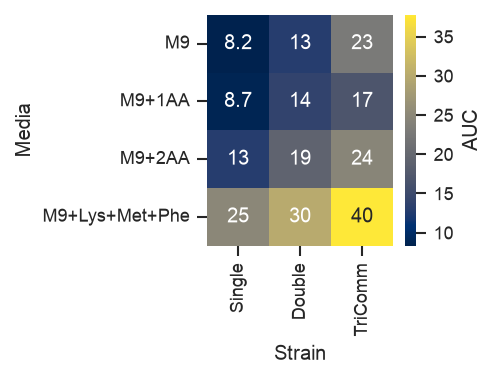

In [17]:
plt.figure(figsize=(2, 2))

hm = sns.heatmap(data=c.T,
            cmap='cividis',
            annot=True,
            robust=True)

hm.figure.axes[-1
    ].set_ylabel('AUC')

plt.xlabel('Strain')
plt.ylabel('Media')

plt.savefig('curves_auc_hm.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('curves_auc_hm.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

In [18]:
mu1 = pd.read_csv('../data/batch/rep_1_mu.tsv', sep='\t')
mu2 = pd.read_csv('../data/batch/rep_2_mu.tsv', sep='\t')
mu = pd.concat([mu1, mu2])
mu['replicate'] = ['rep1' if x == 'growth_rate_20260720'
                   else 'rep2'
                   for x in mu['experiment'].values]

In [19]:
mu['scateg'] = [ds[x] for x in mu['strain'].values]
mu['mcateg'] = [dm[x] for x in mu['treatment'].values]

/home/galmar/miniforge3/envs/2026_tricomm/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 8.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


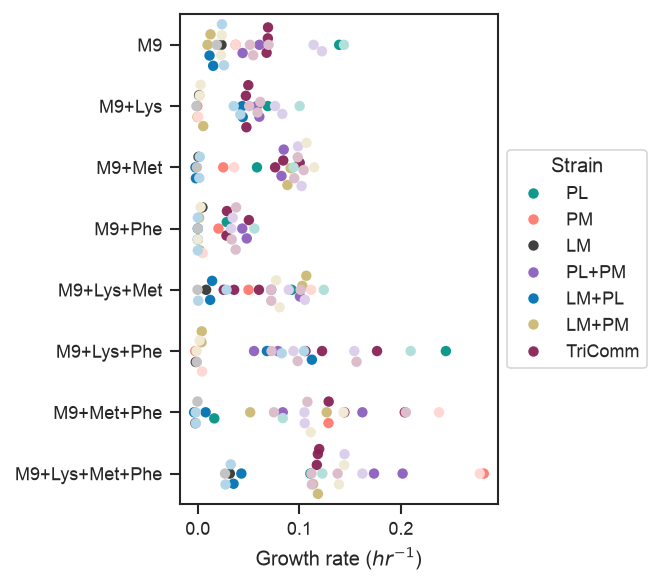

In [20]:
fig, ax = plt.subplots(figsize=(4.5, 4))

a1 = mu[mu["replicate"] == "rep1"]
a2 = mu[mu["replicate"] == "rep2"]

sns.swarmplot(
    data=a1,
    y="treatment",
    x="grate",
    hue="strain",
    order=media_order,
    hue_order=strains_order,
    palette=base_colors,
    alpha=0.95,
    ax=ax
)

light_palette = [lighten_color(x, 0.7) for x in base_colors]

sns.swarmplot(
    data=a2,
    y="treatment",
    x="grate",
    hue="strain",
    order=media_order,
    hue_order=strains_order,
    palette=light_palette,
    # alpha=0.7,
    ax=ax
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:len(strains_order)], labels[:len(strains_order)],
          title="Strain", bbox_to_anchor=(1, 0.5), loc="center left",
          facecolor='w')

ax.set(xlabel="Growth rate ($hr^{-1}$)", ylabel="", 
       # xlim=(-1, 41)
      )
sns.despine(top=False, right=False)
plt.tight_layout()

plt.savefig('curves_mu_all.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('curves_mu_all.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

In [21]:
bu = mu.pivot_table(index='strain', columns='treatment', values='grate',
                    aggfunc='mean'
                   ).reindex(strains_order).reindex(media_order, axis=1)

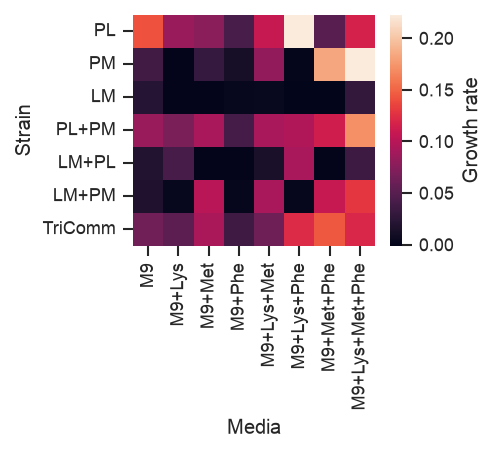

In [22]:
plt.figure(figsize=(2.6, 2))

# use smaller font sizes for this one
with sns.axes_style('ticks', rc={'font.size': 5, 'axes.labelsize': 5}):
    hm = sns.heatmap(data=bu,
                     cmap='rocket',
                     # vmax=25,
                     robust=True,
                    )

    hm.figure.axes[-1
        ].set_ylabel('Growth rate')
    
    plt.xlabel('Media')
    plt.ylabel('Strain')

plt.savefig('curves_grate_hm_all.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('curves_grate_hm_all.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

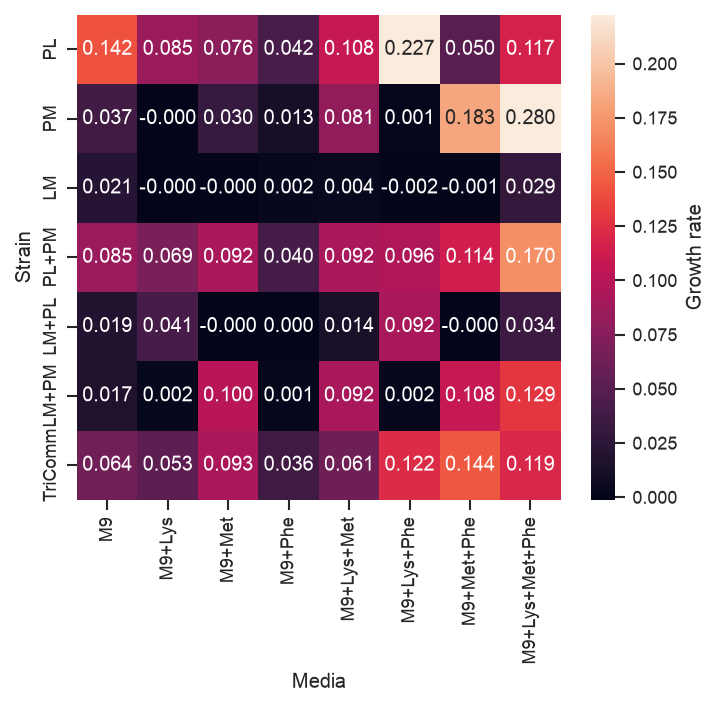

In [23]:
plt.figure(figsize=(5.2, 4.2))

# use smaller font sizes for this one
with sns.axes_style('ticks', rc={'font.size': 5, 'axes.labelsize': 5}):
    hm = sns.heatmap(data=bu,
                     cmap='rocket',
                     # vmax=25,
                     robust=True,
                     annot=True,
                     fmt='.3f'
                    )

    hm.figure.axes[-1
        ].set_ylabel('Growth rate')
    
    plt.xlabel('Media')
    plt.ylabel('Strain');

In [24]:
cu = mu.pivot_table(index='scateg', columns='mcateg', values='grate',
                    aggfunc='mean'
                    ).reindex(['Single', 'Double', 'TriComm'])

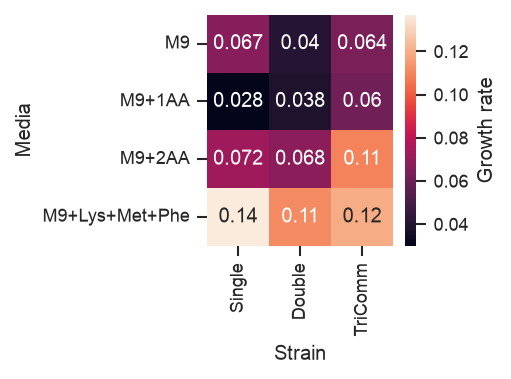

In [25]:
plt.figure(figsize=(2, 2))

hm = sns.heatmap(data=cu.T,
            cmap='rocket',
            annot=True,
            robust=True)

hm.figure.axes[-1
    ].set_ylabel('Growth rate')

plt.xlabel('Strain')
plt.ylabel('Media')

plt.savefig('curves_grate_hm.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('curves_grate_hm.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);